# Assignment 5 Report 

Name: Tianna

Collaborators (if any - humans or not):

References:

https://numpy.org/doc/stable/reference/generated/numpy.logspace.html
https://www.bing.com/search?q=julia+cuda&cvid=2c4e29f932e54e679fa891b4f7dd0c97&gs_lcrp=EgRlZGdlKgYIABBFGDkyBggAEEUYOTIGCAEQLhhAMgYIAhAuGEAyBggDEC4YQDIGCAQQABhAMgYIBRAuGEAyBggGEC4YQDIGCAcQLhhAMgYICBAuGEDSAQgyNjA4ajBqNKgCALACAA&FORM=ANAB01&adppc=EDGEESS&PC=EDBBAN

3) In Report.ipynb explain in your own words what problem the knl_reversevecs_inplace_bad! version has.
   The problem with knl_reversevecs_inplace_bad!
   is with the line:
   a[i] = a[N - i + 1]
   a[1] = a[N]

   If we compare from the previous function: in knl_reversevecs! we have an input vector b that is used to replace a[i]. However, in the knl_reverservecs_inplace_bad we see that a[i] is trying to get replacement values using a[N - i + 1] but we lose the initial value of a[i] before it is lost.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Open the CSV file for reading
results = pd.read_csv('reverse_vec_results.csv', delimiter=',')

results_N = pd.read_csv('reverse_vec_results1.csv', delimiter=',')


In [3]:
results

,Time,Bytes
0,0.022858,0
1,0.016330,0
2,0.000255,240
3,0.000232,160
4,0.000232,160
5,0.000232,160
6,0.000232,160
7,0.000318,240
8,0.000372,160
9,0.000372,160


In [4]:
results_N

,Time,Bytes
0,0.000215,0
1,0.000148,0
2,0.000029,240
3,0.000042,160
4,0.000042,160
5,0.000042,160
6,0.000042,160
7,0.000023,240
8,0.000075,160
9,0.000075,160


In [5]:
#Calculating Bandwidth
N_1 = 10000000
N_2 = 100000

l = len(results)

bandwidth = np.zeros(l)
bandwidth_1 = np.zeros(l)


for i in range(0,l):
    if i <= 5:
        bandwidth[i] = 2*N_1*32/results['Time'][i]
        bandwidth_1[i] = 2*N_2*32/results_N['Time'][i]
    else:
        bandwidth[i] = 2*N_1*64/results['Time'][i]
        bandwidth_1[i] = 2*N_2*64/results_N['Time'][i]

print(f"Bandwidth for N = 10E6 [0:4] FloatType32 [5:10] FloatType64: {bandwidth}")
print(f"\nBandwidth for N = 10E4 [0:4] FloatType32 [5:10] FloatType64: {bandwidth_1}")

Bandwidth for N = 10E6 [0:4] FloatType32 [5:10] FloatType64: [2.79994743e+10 3.91915542e+10 2.50823996e+12 2.75287762e+12
 2.75287762e+12 2.75287762e+12 5.50575523e+12 4.02728485e+12
 3.43826303e+12 3.43826303e+12]

Bandwidth for N = 10E4 [0:4] FloatType32 [5:10] FloatType64: [2.97848972e+10 4.33454565e+10 2.19178082e+11 1.51658768e+11
 1.51658768e+11 1.51658768e+11 3.03317536e+11 5.58951965e+11
 1.71352075e+11 1.71352075e+11]


3) In Report.ipynb provide a bandwidth analysis of the correct knl_reversevecs_inplace! kernel
   I think its interested to note that looking at the data calculated for the first calculation for the bandwidth. This is the N = 10E6 I can see that the changes for Float32 Type we can see that the order of magnitude is relativitly the same until it hits the 3rd function where the bandwidth goes up. This makes sense since the computation time becomes more intense so it should take longer. Especially since it is using CUDA to make these computations, it needs to take more time and bandwidth for gathering the thread and blockID.
   Compared to the bandwidth for 10E4 at FloatType32 the bandwidth is smaller, also makes sense since the N is smaller, they are proportional with each other.

Text(0.5, 1.0, ' 5.1 Performance Analysis Bandwidth for N')

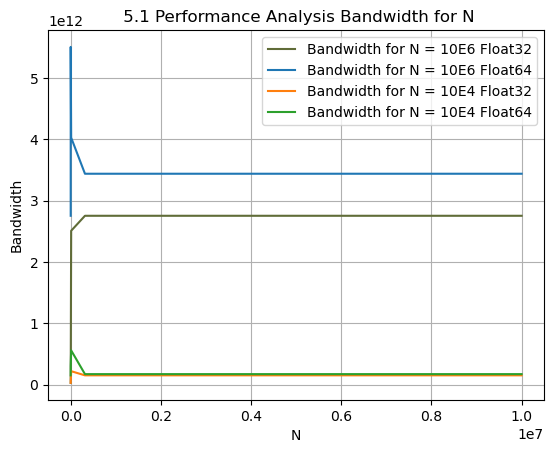

In [6]:
n_iter = np.logspace(1, 7, num = 5)

y_32 = bandwidth[:5]
y_64 = bandwidth[5:10]
y_n32 = bandwidth_1[:5]
y_n64 = bandwidth_1[5:10]

fig, ax = plt.subplots()

ax.plot(n_iter, y_32, label = "Bandwidth for N = 10E6 Float32", color = '#606c38')
ax.plot(n_iter, y_64, label = "Bandwidth for N = 10E6 Float64")
ax.plot(n_iter, y_n32, label = "Bandwidth for N = 10E4 Float32")
ax.plot(n_iter, y_n64, label = "Bandwidth for N = 10E4 Float64")

ax.set_xlabel('N')
ax.set_ylabel('Bandwidth')
ax.legend()
ax.grid(True, which="both")
ax.set_title(" 5.1 Performance Analysis Bandwidth for N")

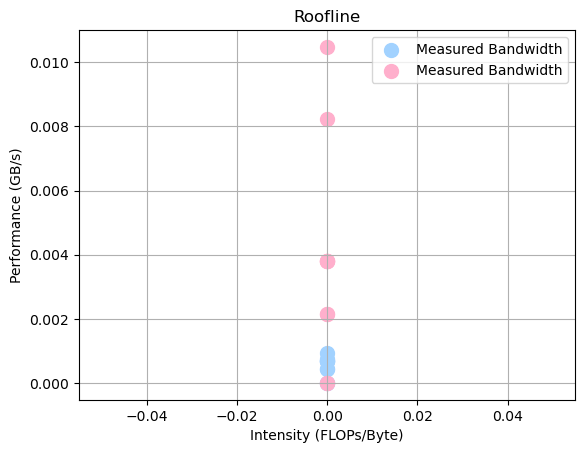

In [7]:
#Roofline Plot
byte = results['Bytes']

achieved_bw = results['Bytes']/results['Time']/1e9
achieved_bw1 = results_N['Bytes']/results_N['Time']/1e9
intensity = np.zeros(l)

plt.scatter(intensity, achieved_bw, color='#a2d2ff', s=100, label='Measured Bandwidth')
plt.scatter(intensity, achieved_bw1, color='#ffafcc', s=100, label='Measured Bandwidth')
plt.xlabel('Intensity (FLOPs/Byte)')
plt.ylabel('Performance (GB/s)')
plt.title('Roofline')
plt.legend()
plt.grid(True, which="both")
plt.show()

### 5) In Report.ipynb add a performance analysis that should produce at least the following two figures and related commentary. 
    
    5.1) Bandwidth vs problem size N (you need to test for different values of N) for Float64 and Float32.
            Looking at the graph we can see that FloatType64 versions have higher bandwidth, this makes sense because its more bytes being used especially for an intensive package like CUDA. There is an error for the start of the graph for N = 10e6 at Float64 on the plotting because I had the bandwidth calculated in 1 array for both Float32 and Float64.

    5.2) A roofline plot (reference Lecture 6).
        This graph shows the Intensity vs Performance. The interesting thing about this code is that it doesn't have an arithmetic processes because of equations just doing data movement inside the array for indexing. If array "a" needed something like array "c" and array "b" and the equation was a[i] = b[i] *c[i]+2 that would be a 2 Flops (for multiplying and adding). I ended assuming that the intensity was 0. For the performance, I just did Bytes/time * 1e9. Something to note between the differences between the two N values is that the N = 10e4 ran faster, this makes sense like before because it doesn't use as much bandwidth or memory so it is more efficient. It's a smaller chunk to consume so to speak.